# 🏥 Insurance Claim Status Predictor
### Complete ML Pipeline — From Data to Saved Model
**Target:** Predict if a claim will be `Approved` or `Rejected`

## Step 1 — Install & Import Libraries

In [1]:
# Run this once to install dependencies
# !pip install pandas scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import pickle
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2 — Load & Explore the Dataset

In [2]:
df = pd.read_csv('dataset.csv')  # make sure dataset.csv is in the same folder

print('Shape:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())
df.head()

Shape: (15000, 58)

Column names:
['age', 'gender', 'is_senior_citizen', 'vulnerable_category', 'ped_type', 'continuous_coverage_months', 'ped_waiting_period_served', 'specific_disease_waiting_period_served', 'grace_period_status', 'portability_status', 'sum_insured_enhanced', 'sum_insured_inr', 'annual_premium_inr', 'policy_zone', 'diagnosis_category', 'treatment_system', 'is_modern_treatment', 'hospital_accreditation', 'hospitalization_type', 'hospital_zone', 'admission_type', 'days_hospitalised', 'length_of_stay_hours', 'active_treatment_flag', 'hospital_risk_score', 'provider_blacklist_flag', 'investigation_triggered', 'investigation_outcome', 'claim_amount_inr', 'standard_rate_inr', 'standard_rate_deviation_pct', 'claim_coverage_ratio', 'bill_structure', 'non_medical_expenses_pct', 'non_medical_deduction_inr', 'disease_sub_limit_applies', 'sub_limit_amount_inr', 'disease_sub_limit_capped', 'sub_limit_excess_amount_inr', 'zone_mismatch', 'zone_copay_amount_inr', 'mandatory_copay_pc

,age,gender,is_senior_citizen,vulnerable_category,ped_type,continuous_coverage_months,ped_waiting_period_served,specific_disease_waiting_period_served,grace_period_status,portability_status,...,claim_submission_timeline_days,free_look_cancellation,document_submission_mode,document_status,previous_claims_count,settled_amount_inr,settlement_ratio_pct,claim_settlement_type,claim_status,rejection_reason
0,62,Male,True,PwD,Hypertension_Diabetes,100,True,True,Active,False,...,36,False,By_Patient,Complete,1,61485,39.09,Partial,Approved,NaN
1,34,Male,False,PwD,Hypertension,36,True,True,Active,False,...,5,False,By_Hospital,Complete,2,144724,46.58,Partial,Approved,NaN
2,30,Male,False,PwD,Diabetes,50,True,True,In_Grace_Period,False,...,3,False,By_Patient,Complete,2,31149,88.58,Partial,Approved,NaN
3,39,Male,False,PwD,Hypertension,29,False,False,Active,False,...,6,False,By_Hospital,Incomplete,2,0,0.00,Rejected,Rejected,PED_Waiting_Period_Not_Served
4,31,Male,False,PwD,Heart_Disease,10,False,False,Active,False,...,5,False,By_Patient,Complete,1,0,0.00,Rejected,Rejected,PED_Waiting_Period_Not_Served


Claim Status Distribution:
claim_status
Rejected    7595
Approved    7405
Name: count, dtype: int64

Percentages:
claim_status
Rejected    50.63
Approved    49.37
Name: proportion, dtype: float64


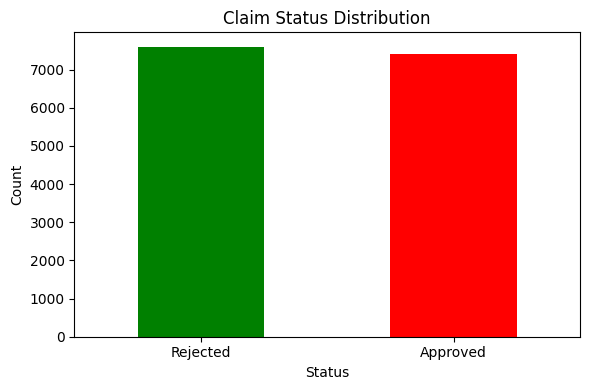

In [3]:
# Check target column distribution
print('Claim Status Distribution:')
print(df['claim_status'].value_counts())
print('\nPercentages:')
print(df['claim_status'].value_counts(normalize=True).mul(100).round(2))

df['claim_status'].value_counts().plot(kind='bar', color=['green','red'], figsize=(6,4))
plt.title('Claim Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
# Check for missing values
missing = df.isnull().sum()
print('Columns with missing values:')
print(missing[missing > 0])

Columns with missing values:
rejection_reason    7405
dtype: int64


## Step 3 — Preprocessing

In [5]:
# Drop columns that would leak the answer or are not useful
# rejection_reason, settled_amount, settlement_ratio all come AFTER a decision is made
drop_cols = [
    'claim_status',          # this is our TARGET
    'rejection_reason',      # only known after rejection — data leakage!
    'settled_amount_inr',    # only known after approval — data leakage!
    'settlement_ratio_pct',  # same reason
    'claim_settlement_type'  # same reason
]

X = df.drop(columns=drop_cols)
y = (df['claim_status'] == 'Approved').astype(int)  # 1=Approved, 0=Rejected

print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('Target values: 1=Approved, 0=Rejected')
print(y.value_counts())

Features shape: (15000, 53)
Target shape: (15000,)
Target values: 1=Approved, 0=Rejected
claim_status
0    7595
1    7405
Name: count, dtype: int64


In [6]:
# Convert boolean columns to integers (True->1, False->0)
bool_cols = X.select_dtypes(include='bool').columns.tolist()
print('Boolean columns:', bool_cols)
for col in bool_cols:
    X[col] = X[col].astype(int)

Boolean columns: ['is_senior_citizen', 'ped_waiting_period_served', 'specific_disease_waiting_period_served', 'portability_status', 'sum_insured_enhanced', 'is_modern_treatment', 'active_treatment_flag', 'provider_blacklist_flag', 'investigation_triggered', 'disease_sub_limit_applies', 'disease_sub_limit_capped', 'zone_mismatch', 'disclosure_of_material_fact', 'fraud_indicator', 'free_look_cancellation']


In [7]:
# Encode categorical columns using LabelEncoder
# We save each encoder so we can reuse it in the app
cat_cols = X.select_dtypes(include='object').columns.tolist()
print('Categorical columns to encode:', cat_cols)

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le
    print(f'{col}: {list(le.classes_)}')

Categorical columns to encode: ['gender', 'vulnerable_category', 'ped_type', 'grace_period_status', 'policy_zone', 'diagnosis_category', 'treatment_system', 'hospital_accreditation', 'hospitalization_type', 'hospital_zone', 'admission_type', 'investigation_outcome', 'bill_structure', 'pre_auth_status', 'document_submission_mode', 'document_status']


C:\Users\user\AppData\Local\Temp\ipykernel_9768\4254419978.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


gender: ['Female', 'Male']
vulnerable_category: ['HIV_AIDS', 'Mental_Illness', 'PwD']
ped_type: ['Asthma', 'Diabetes', 'Heart_Disease', 'Hypertension', 'Hypertension_Diabetes']
grace_period_status: ['Active', 'In_Grace_Period', 'Lapsed']
policy_zone: ['Zone_A', 'Zone_B', 'Zone_C']
diagnosis_category: ['Cancer', 'Cardiac', 'Cataract', 'Diabetes_Complications', 'General_Surgery', 'Hernia', 'Kidney_Stones', 'Maternity', 'Mental_Health', 'Orthopedic']
treatment_system: ['AYUSH', 'Allopathy']
hospital_accreditation: ['Government_Recognized', 'NABH_Accredited', 'Non_NABH', 'Unregistered']
hospitalization_type: ['Network', 'Non_Network']
hospital_zone: ['Zone_A', 'Zone_B', 'Zone_C']
admission_type: ['Emergency', 'Planned']
investigation_outcome: ['Cleared', 'Fraud_Confirmed', 'Inconclusive', 'Not_Investigated', 'Overcharging_Found']
bill_structure: ['Consolidated', 'Disputed', 'Itemised']
pre_auth_status: ['Approved', 'Not_Requested', 'Not_Required', 'Rejected']
document_submission_mode: ['By

## Step 4 — Split Data

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training samples:', X_train.shape[0])
print('Testing samples: ', X_test.shape[0])

Training samples: 12000
Testing samples:  3000


## Step 5 — Train Model

In [9]:
model = RandomForestClassifier(
    n_estimators=200,   # number of trees
    random_state=42,    # for reproducibility
    n_jobs=-1           # use all CPU cores
)

print('Training model... (this may take 30-60 seconds)')
model.fit(X_train, y_train)
print('Training complete!')

Training model... (this may take 30-60 seconds)
Training complete!


## Step 6 — Evaluate Model

In [10]:
y_pred = model.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, y_pred) * 100, 2), '%')
print('\nDetailed Report:')
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))

Accuracy: 99.23 %

Detailed Report:
              precision    recall  f1-score   support

    Rejected       1.00      0.99      0.99      1519
    Approved       0.99      1.00      0.99      1481

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



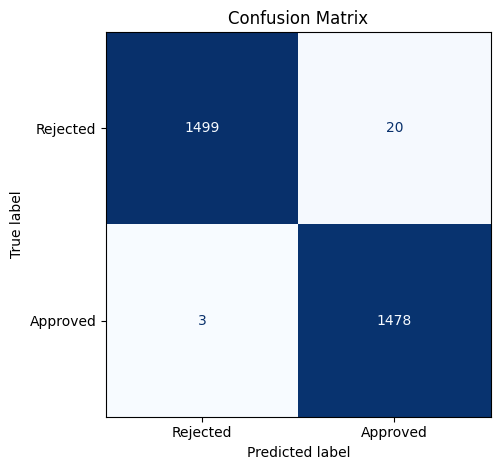

In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Rejected', 'Approved'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

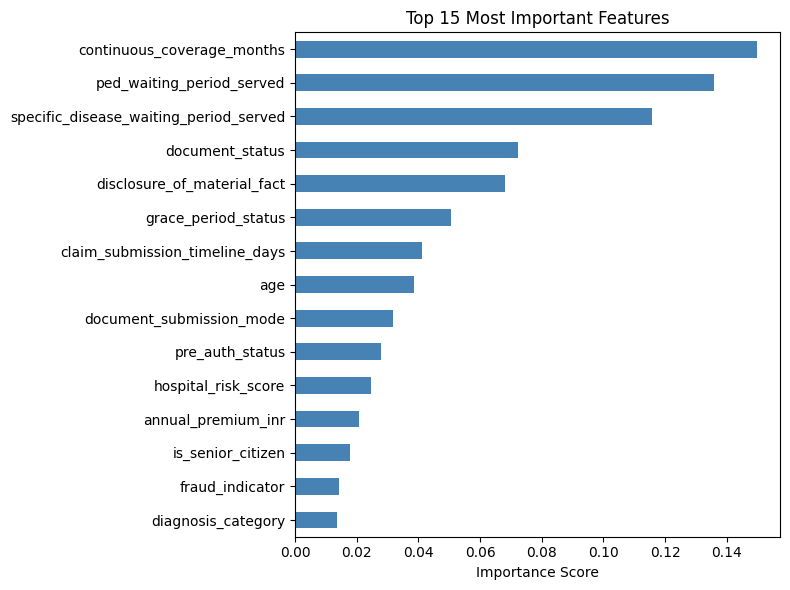

In [12]:
# Top 15 most important features
feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp.sort_values(ascending=False).head(15).plot(
    kind='barh', figsize=(8, 6), color='steelblue'
)
plt.title('Top 15 Most Important Features')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Step 7 — Save Model with Pickle ✅
> This is the key step that connects your notebook to the Streamlit app

In [13]:
# Save the trained model
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)
print('✅ model.pkl saved')

# Save the label encoders (so app.py can encode new inputs the same way)
with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)
print('✅ encoders.pkl saved')

# Save the column order (important! the model expects columns in exact order)
with open('columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)
print('✅ columns.pkl saved')

# Save metadata for the UI (dropdown options, accuracy, etc.)
meta = {
    'cat_cols': cat_cols,
    'bool_cols': bool_cols,
    'cat_options': {col: list(encoders[col].classes_) for col in cat_cols},
    'accuracy': round(accuracy_score(y_test, y_pred) * 100, 2)
}
with open('meta.json', 'w') as f:
    json.dump(meta, f)
print('✅ meta.json saved')

print('\n🎉 All files saved! Copy these 4 files to your app folder:')
print('   model.pkl, encoders.pkl, columns.pkl, meta.json')

✅ model.pkl saved
✅ encoders.pkl saved
✅ columns.pkl saved
✅ meta.json saved

🎉 All files saved! Copy these 4 files to your app folder:
   model.pkl, encoders.pkl, columns.pkl, meta.json


## Step 8 — Test loading the model (verify it works)
> Always test that pickle saved correctly before deploying

In [14]:
# Load model back from disk and test
loaded_model    = pickle.load(open('model.pkl', 'rb'))
loaded_encoders = pickle.load(open('encoders.pkl', 'rb'))
loaded_columns  = pickle.load(open('columns.pkl', 'rb'))
loaded_meta     = json.load(open('meta.json', 'r'))

# Quick sanity check
test_pred = loaded_model.predict(X_test[:5])
labels    = ['Rejected' if p == 0 else 'Approved' for p in test_pred]
print('Test predictions on first 5 rows:', labels)
print('\n✅ Model loads correctly and makes predictions!')
print('✅ Your app is ready to run with: streamlit run app.py')

Test predictions on first 5 rows: ['Approved', 'Rejected', 'Rejected', 'Rejected', 'Rejected']

✅ Model loads correctly and makes predictions!
✅ Your app is ready to run with: streamlit run app.py
